# Project Overview
Credit card fraud is a major financial challenge that can lead to significant losses for banks and customers. The objective of this project is to identify fraudulent transactions by detecting unusual patterns and anomalies in transaction data. The project focuses on data analysis, preprocessing, feature engineering, and visualization to understand transaction behavior. Anomaly detection techniques such as Isolation Forest and Local Outlier Factor (LOF) are used to identify suspicious transactions that deviate from normal patterns. The system aims to detect previously unseen fraud patterns and provide early insights into potentially fraudulent activities

# Step 1: Load Important Modules

In [10]:
# Standard library
import warnings
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
)

# Imbalance handling and boosting models
import imblearn
import xgboost
import lightgbm

# Saving the trained model
import joblib

# Global settings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 42

print("All imports OK")
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost     :", xgboost.__version__)
print("lightgbm    :", lightgbm.__version__)
print("imblearn    :", imblearn.__version__)

All imports OK
pandas      : 2.2.3
scikit-learn: 1.6.1
xgboost     : 3.4.1
lightgbm    : 4.6.0
imblearn    : 0.14.2


# Step 2: Load Data

In [11]:
url="https://github.com/Parthik73/Credit-Card-Fraud-Detection-Using-Anomaly-Detection-Techniques/raw/refs/heads/main/data/creditcard.csv"
df = pd.read_csv(url)
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")

Rows: 284,807   Columns: 31


# Step 3: EDA(Exploratory Data Analysis)

In [12]:
# Step 3.1: Show df data sample
df.sample(5, random_state=42)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,-14.110184,5.299236,-10.834006,1.671120,-9.373859,0.360806,-9.899247,-19.236292,-8.398552,3.101735,-1.514923,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
49906,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,-0.565012,-0.087670,0.979427,0.076883,-0.217884,-0.136830,-2.142892,0.126956,1.752662,0.432546,0.506044,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
29474,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,0.756801,0.543827,0.112453,1.075384,-0.245772,0.180483,1.769860,-0.533172,-0.533300,1.192245,0.212877,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
276481,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,-1.376648,-1.328335,0.223621,1.132627,-0.550875,0.616568,0.497974,0.502195,0.981343,0.101264,-0.244633,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
278846,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,0.259452,0.942162,0.850038,-0.616166,0.592634,-0.603845,0.091077,-0.471867,-0.333816,0.404711,-0.255293,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


In [13]:
# Step 3.2: Show df shape and size
print("df shape :- ", df.shape)
print("df size :- ", df.size)

df shape :-  (284807, 31)
df size :-  8829017


In [14]:
# Step 3.3: Show column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [15]:
# Step 3.4: Check missing values
print("Total missing values :- ", df.isnull().sum().sum())
df.isnull().sum().sort_values(ascending=False).head()
# isnull(): marks missing cells as True, sum(): counts them per column

Total missing values :-  0


,0
Time,0
V1,0
V2,0
V3,0
V4,0


In [16]:
# Step 3.5: Check duplicate rows
dup_count = df.duplicated().sum()
print("Duplicate rows :- ", dup_count)
print("Duplicate share :- ", f"{dup_count / len(df):.2%}")
print("Fraud rows among duplicates :- ", df[df.duplicated()]["Class"].sum())

Duplicate rows :-  1081
Duplicate share :-  0.38%
Fraud rows among duplicates :-  19


In [17]:
# Step 3.6: Divide columns into required objects
target_column = "Class"
original_columns = ["Time", "Amount"]
pca_columns = [c for c in df.columns if c.startswith("V")]

print("Target Column :- ", target_column)
print("="*100)
print("Original Columns :- ", original_columns)
print("="*100)
print("PCA Columns :- ", len(pca_columns), "->", pca_columns[0], "to", pca_columns[-1])
# V1-V28 are anonymised PCA components; only Time and Amount are the real columns

Target Column :-  Class
Original Columns :-  ['Time', 'Amount']
PCA Columns :-  28 -> V1 to V28


In [18]:
# Step 3.7: Show stats of Time and Amount
df[original_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.859575,47488.145955,0.0,54201.5,84692.0,139320.500,172792.00
Amount,284807.0,88.349619,250.120109,0.0,5.6,22.0,77.165,25691.16


In [19]:
# Step 3.8: Show stats of PCA features
df[pca_columns].describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
V1,0.0,1.96,-56.41,2.45
V2,0.0,1.65,-72.72,22.06
V3,-0.0,1.52,-48.33,9.38
V4,0.0,1.42,-5.68,16.88
V5,0.0,1.38,-113.74,34.80
V6,0.0,1.33,-26.16,73.30
V7,-0.0,1.24,-43.56,120.59
V8,0.0,1.19,-73.22,20.01
V9,-0.0,1.10,-13.43,15.59
V10,0.0,1.09,-24.59,23.75


,Count,Percent
Legitimate (0),284315,99.827
Fraud (1),492,0.173



1 fraud for every 578 legitimate transactions


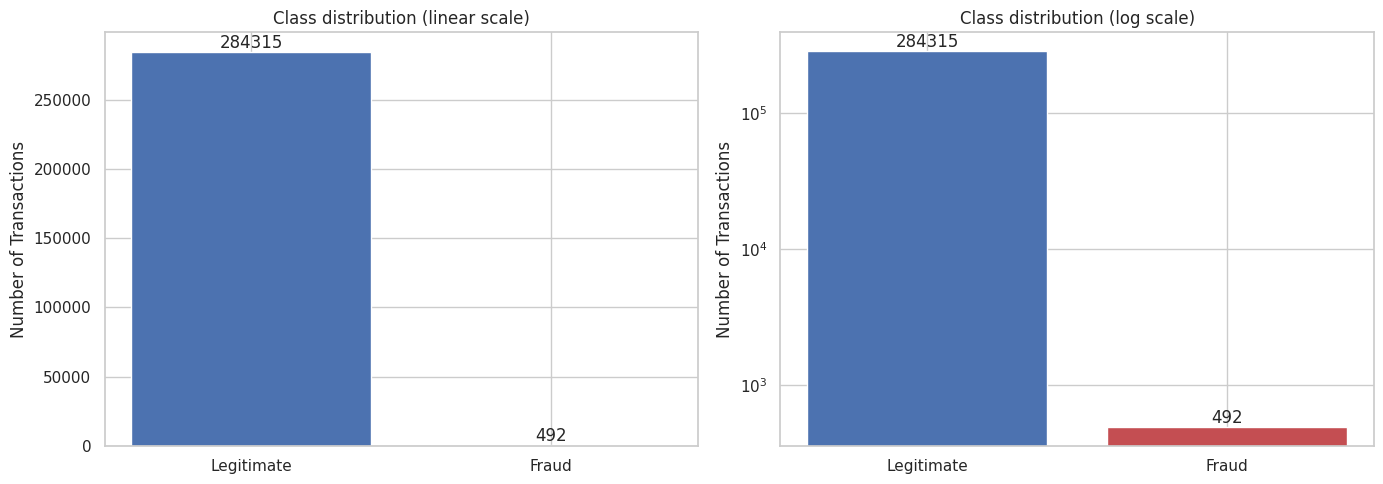

In [20]:
# Step 3.9: Show target (Class) distribution
counts = df["Class"].value_counts().sort_index()
percent = (df["Class"].value_counts(normalize=True).sort_index() * 100).round(3)

class_summary = pd.DataFrame({"Count": counts, "Percent": percent})
class_summary.index = ["Legitimate (0)", "Fraud (1)"]
display(class_summary)

print(f"\n1 fraud for every {counts[0] / counts[1]:.0f} legitimate transactions")

plt.figure(figsize=(14,5))
for i, scale in enumerate(["linear", "log"]):
    plt.subplot(1,2,i+1)
    plt.title(f"Class distribution ({scale} scale)")
    ax = plt.bar(["Legitimate", "Fraud"], counts.values, color=["#4C72B0", "#C44E52"])
    plt.bar_label(ax)
    plt.yscale(scale)
    plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# log scale is used because fraud bar is invisible on the normal scale

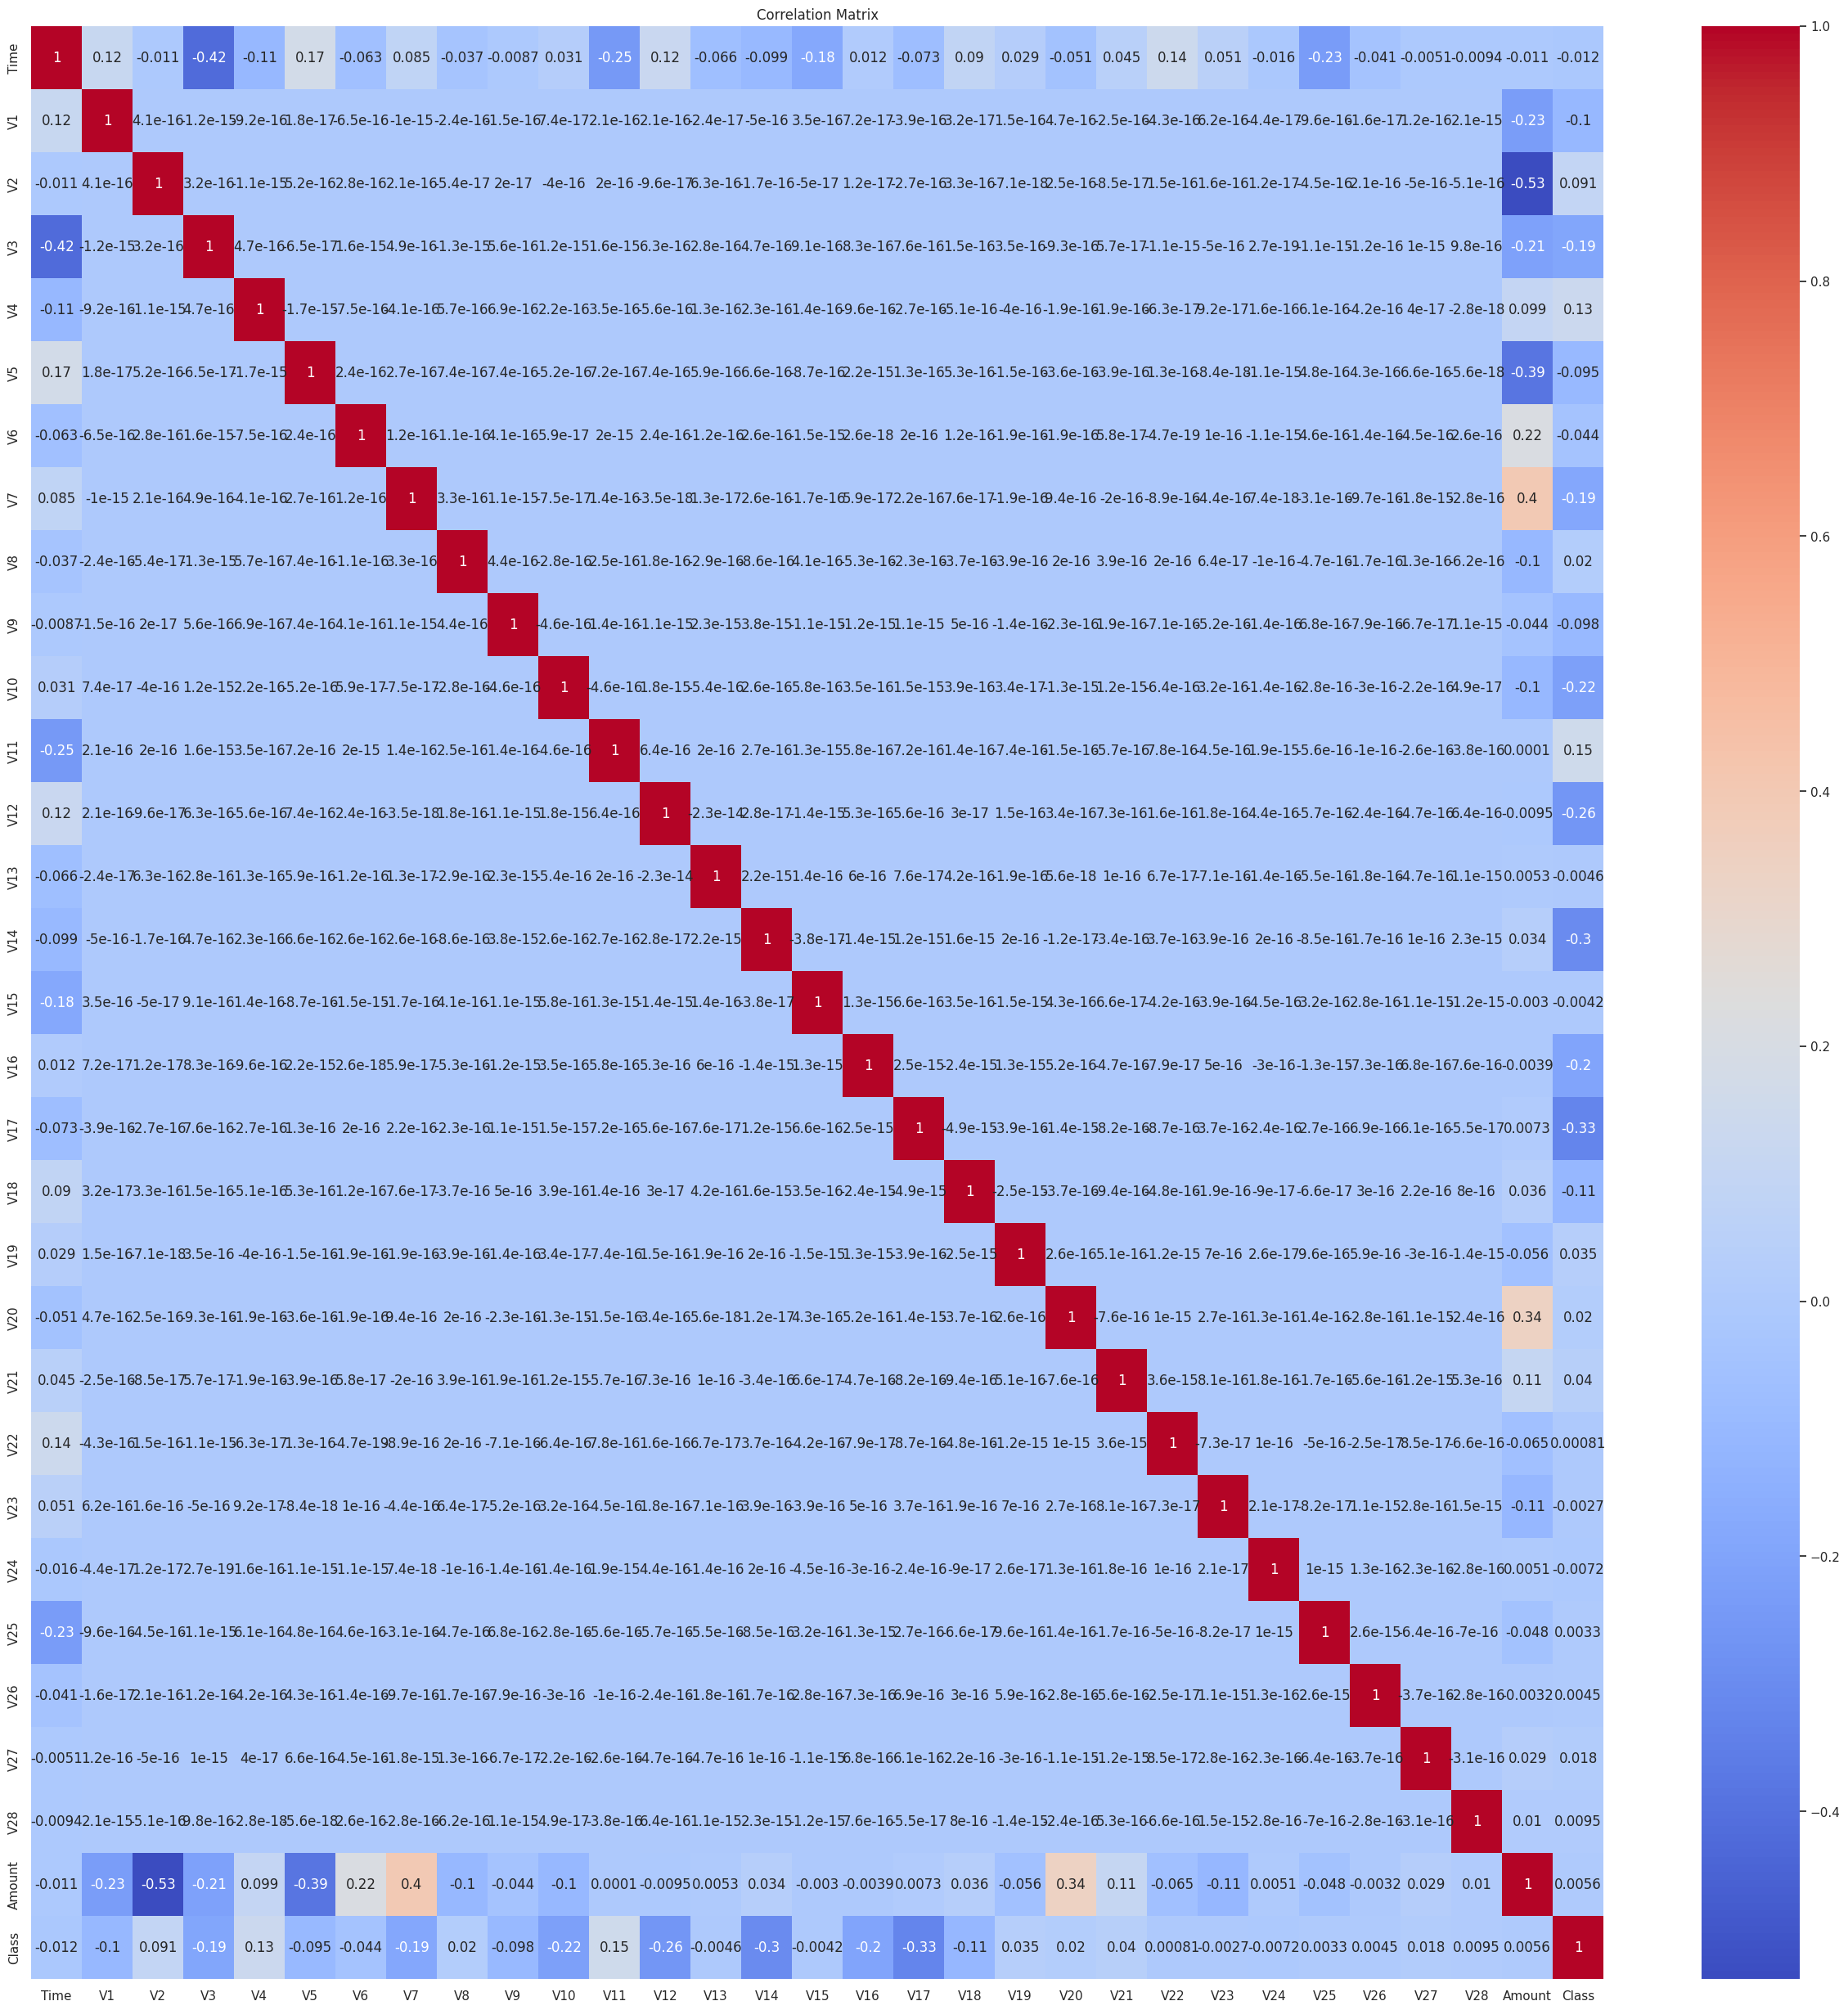

In [25]:
# Step 3.10: Show Correlation Matrix
plt.figure(figsize=(31,31))
plt.title("Correlation Matrix")
sns.heatmap(df.corr(), cmap="coolwarm",annot=True)
plt.show()